# 16 - Threshold Analysis

## Scientific Objectives

Test the three research hypotheses by identifying critical thresholds:

- **H1**: Lakes with area/depth ratio > X have 10x higher GLOF probability
- **H2**: Lake growth rate (dA/dt) is a better predictor than absolute size
- **H3**: There exists a 'critical zone' of glacier-lake distance where risk is maximum (non-monotonic)

**Input**: `models/best_model.joblib`, `data/processed/labeled/training_data.csv`
**Output**: `data/processed/threshold_summary.csv`, figures in `figures/thresholds/`

In [1]:
# --- GLOF PROJECT STANDARD SETUP ---
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
try:
    import geopandas as gpd
except ImportError:
    pass

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

import importlib
import src.gpu_utils
importlib.reload(src.gpu_utils)

# Fix PROJ: usar proj.db de rasterio (v1.6) en vez del de pyproj (v1.4)
if 'PROJ_LIB' in os.environ:
    del os.environ['PROJ_LIB']
try:
    import rasterio as _rio
    _proj_data = Path(_rio.__file__).parent / 'proj_data'
    if _proj_data.exists():
        os.environ['PROJ_LIB'] = str(_proj_data)
    del _rio, _proj_data
except Exception:
    pass

from src.gpu_utils import GPUConfig, gpu_array, cpu_array
gpu_config = GPUConfig()
print(gpu_config)

GPU_AVAILABLE = gpu_config.has_gpu
CUPY_AVAILABLE = gpu_config.cupy_available

GPU CONFIGURATION
GPU Available: True
Device: NVIDIA GeForce RTX 3050 Laptop GPU
Device Count: 1
Memory Total: 4.0 GB
Memory Free: 2.9 GB
CUDA Version: 595.58.03

Library Support:
  - CuPy:         yes
  - PyTorch CUDA: no
  - Numba CUDA:   yes


In [2]:
# Imports specific to this notebook
import json
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import spearmanr, mannwhitneyu

try:
    from sklearn.inspection import partial_dependence
    SKLEARN_PD_AVAILABLE = True
except ImportError:
    SKLEARN_PD_AVAILABLE = False

print('Imports complete.')
print(f'  sklearn partial dependence: {SKLEARN_PD_AVAILABLE}')

Imports complete.
  sklearn partial dependence: True


In [3]:
# =============================================================================
# CONFIGURATION
# =============================================================================
DATA_DIR = project_root / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
MODELS_DIR = project_root / 'models'
FIG_DIR = project_root / 'figures' / 'thresholds'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
})

NON_FEATURE_COLS = [
    'had_glof', 'lake_id', 'geometry', 'index',
    'glof_date', 'source', 'fid', 'id', 'name',
]

print(f'Project root : {project_root}')
print(f'Models dir   : {MODELS_DIR}')
print(f'Processed dir: {PROCESSED_DIR}')
print(f'Figures dir  : {FIG_DIR}')

Project root : /home/andre/Documents/GLOF_Andes_Project-Paper
Models dir   : /home/andre/Documents/GLOF_Andes_Project-Paper/models
Processed dir: /home/andre/Documents/GLOF_Andes_Project-Paper/data/processed
Figures dir  : /home/andre/Documents/GLOF_Andes_Project-Paper/figures/thresholds


## 1. Load Model and Data

In [4]:
# Load best model
model = None
model_path = MODELS_DIR / 'best_model.joblib'

if model_path.exists():
    model = joblib.load(model_path)
    print(f'Loaded model : {type(model).__name__}')
else:
    print(f'WARNING: Model not found at {model_path}')
    print('         Run notebook 15_model_training.ipynb first.')

Loaded model : BalancedRandomForestClassifier


In [5]:

# Load training data, apply MISMO feature engineering que NB15, y predecir probabilidades
X = None
y = None
y_prob = None
df = None

train_path         = PROCESSED_DIR / 'labeled' / 'training_data.csv'
feature_names_path = MODELS_DIR / 'feature_names.json'

if train_path.exists():
    df = pd.read_csv(train_path)
    print(f'Loaded data  : {df.shape[0]} rows x {df.shape[1]} cols')

    # ── Ingeniería de features IDÉNTICA a NB15 cell-4 ──────────────────
    # (necesario para que las columnas log_* existan antes de filtrar)
    exclude_cols = [
        'lake_id', 'glof_label', 'country', 'cordillera',
        'geometry', 'year', 'source', 'area_name', 'scene_date',
        'glof_volume_m3', 'glof_match_dist_m',
        'glof_date', 'glof_trigger', 'glof_lake_name',
    ]
    base_cols = [c for c in df.columns
                 if c not in exclude_cols
                 and df[c].dtype in ['float64', 'float32', 'int64', 'int32']]
    X_raw = df[base_cols].copy()
    X_raw = X_raw.fillna(X_raw.median(numeric_only=True)).fillna(0)

    # Log-transforms
    log_cols = [c for c in ['area_m2', 'perimeter_m', 'volume_m3', 'equivalent_diameter_m',
                             'potential_energy', 'depth_m', 'dam_height',
                             'area_2017_est', 'area_2025_est', 'total_growth_m2']
                if c in X_raw.columns]
    for c in log_cols:
        X_raw[f'log_{c}'] = np.log1p(X_raw[c].clip(lower=0))

    if 'total_growth_m2' in X_raw.columns and 'area_2017_est' in X_raw.columns:
        X_raw['rel_growth'] = X_raw['total_growth_m2'] / (X_raw['area_2017_est'] + 1)
    if 'slope_mean' in X_raw.columns and 'log_area_m2' in X_raw.columns:
        X_raw['slope_x_logarea'] = X_raw['slope_mean'] * X_raw['log_area_m2']
    if 'dist_glacier_m' in df.columns:
        X_raw['no_glacier'] = (df['dist_glacier_m'].isna()).astype(int)

    # ── Filtrar a feature_cols exactas de NB15 ─────────────────────────
    if feature_names_path.exists():
        with open(feature_names_path) as f:
            feature_cols = json.load(f)
        missing = [c for c in feature_cols if c not in X_raw.columns]
        if missing:
            print(f'WARNING: {len(missing)} features de NB15 no encontradas: {missing[:5]}')
        feature_cols = [c for c in feature_cols if c in X_raw.columns]
        X = X_raw[feature_cols].copy()
        print(f'Features (desde feature_names.json): {len(feature_cols)}')
    else:
        X = X_raw.copy()
        feature_cols = list(X.columns)
        print(f'WARNING: feature_names.json no encontrado — usando todas las features ({len(feature_cols)})')

    # Target
    if 'glof_label' in df.columns:
        y = df['glof_label'].astype(int).values
    elif 'had_glof' in df.columns:
        y = df['had_glof'].astype(int).values
    else:
        y = np.zeros(len(df), dtype=int)

    print(f'Feature matrix : {X.shape}')
    print(f'Target (y=1)   : {int(y.sum())} GLOFs de {len(y)}')
else:
    print(f'WARNING: Training data no encontrado en {train_path}')

# Predicted probabilities
if model is not None and X is not None:
    y_prob = model.predict_proba(X)[:, 1]
    print(f'\nProbabilidades predichas: min={y_prob.min():.4f}, max={y_prob.max():.4f}, mean={y_prob.mean():.4f}')


Loaded data  : 12588 rows x 56 cols
Features (desde feature_names.json): 58
Feature matrix : (12588, 58)
Target (y=1)   : 16 GLOFs de 12588

Probabilidades predichas: min=0.0120, max=1.0000, mean=0.3295


## 2. Hypothesis 1: Area/Depth Ratio Threshold

**H1**: Lakes with area/depth ratio > X have 10x higher GLOF probability.

Wide, shallow lakes should have geometrically different failure modes than narrow deep lakes.

In [6]:
def find_optimal_threshold(feature_values, y_true, y_prob, n_bins=20):
    """
    Find the optimal threshold for a feature by binning values and
    computing the risk ratio (mean probability above vs below threshold).

    Parameters
    ----------
    feature_values : array-like
        Feature values (1D).
    y_true : array-like
        Binary labels.
    y_prob : array-like
        Predicted probabilities for the positive class.
    n_bins : int
        Number of quantile bins.

    Returns
    -------
    dict with keys:
        threshold_value, risk_ratio, p_value, bin_centers, bin_probs,
        risk_below, risk_above
    """
    feature_values = np.asarray(feature_values, dtype=float)
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)

    # Remove NaN
    valid = ~np.isnan(feature_values)
    fv = feature_values[valid]
    yp = y_prob[valid]
    yt = y_true[valid]

    if len(fv) < 10:
        return None

    # Quantile bins
    percentiles = np.linspace(0, 100, n_bins + 1)
    bin_edges = np.percentile(fv, percentiles)
    bin_edges = np.unique(bin_edges)

    bin_centers = []
    bin_probs = []

    for i in range(len(bin_edges) - 1):
        mask = (fv >= bin_edges[i]) & (fv < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_centers.append((bin_edges[i] + bin_edges[i + 1]) / 2)
            bin_probs.append(yp[mask].mean())

    bin_centers = np.array(bin_centers)
    bin_probs = np.array(bin_probs)

    if len(bin_probs) < 2:
        return None

    # Find threshold: bin where risk ratio vs. lowest bin is maximised
    base_risk = bin_probs[0] + 1e-9
    risk_ratios = bin_probs / base_risk
    best_bin_idx = np.argmax(risk_ratios)

    if best_bin_idx > 0:
        threshold_value = (bin_centers[best_bin_idx - 1] + bin_centers[best_bin_idx]) / 2
    else:
        threshold_value = bin_centers[0]

    # Mann-Whitney U test: values below vs above threshold
    below_mask = fv < threshold_value
    above_mask = fv >= threshold_value

    risk_below = yp[below_mask].mean() if below_mask.sum() > 0 else 0.0
    risk_above = yp[above_mask].mean() if above_mask.sum() > 0 else 0.0
    risk_ratio = (risk_above + 1e-9) / (risk_below + 1e-9)

    p_value = 1.0
    if below_mask.sum() >= 5 and above_mask.sum() >= 5:
        stat, p_value = mannwhitneyu(yp[below_mask], yp[above_mask], alternative='less')

    return {
        'threshold_value': threshold_value,
        'risk_ratio': risk_ratio,
        'risk_below': risk_below,
        'risk_above': risk_above,
        'p_value': p_value,
        'bin_centers': bin_centers,
        'bin_probs': bin_probs,
        'n_below': int(below_mask.sum()),
        'n_above': int(above_mask.sum()),
    }

print('find_optimal_threshold() defined.')

find_optimal_threshold() defined.


In [7]:
# Apply H1 analysis to area_depth_ratio (or proxy)
h1_result = None
h1_feature_col = None

if X is not None and y_prob is not None:
    candidate_cols = ['area_depth_ratio', 'area_m2', 'lake_area']
    for col in candidate_cols:
        if col in X.columns:
            h1_feature_col = col
            break

    if h1_feature_col:
        print(f'H1 analysis using feature: {h1_feature_col}')
        h1_result = find_optimal_threshold(
            X[h1_feature_col].values, y, y_prob, n_bins=20
        )

        if h1_result:
            print(f"  Threshold value : {h1_result['threshold_value']:.4f}")
            print(f"  Risk below      : {h1_result['risk_below']:.3f}")
            print(f"  Risk above      : {h1_result['risk_above']:.3f}")
            print(f"  Risk ratio      : {h1_result['risk_ratio']:.2f}x")
            print(f"  p-value (MWU)   : {h1_result['p_value']:.4f}")
            print(f"  N below         : {h1_result['n_below']}")
            print(f"  N above         : {h1_result['n_above']}")
            confirmed = h1_result['risk_ratio'] >= 10.0
            print(f"  H1 confirmed (10x threshold): {confirmed}")
    else:
        print('WARNING: No area/depth ratio feature found in dataset.')
        print(f'  Available columns: {list(X.columns)}')
else:
    print('WARNING: Model or data not loaded — skipping H1 analysis.')

H1 analysis using feature: area_depth_ratio
  Threshold value : 493457.1731
  Risk below      : 0.329
  Risk above      : 0.856
  Risk ratio      : 2.60x
  p-value (MWU)   : 1.0000
  N below         : 12587
  N above         : 1
  H1 confirmed (10x threshold): False


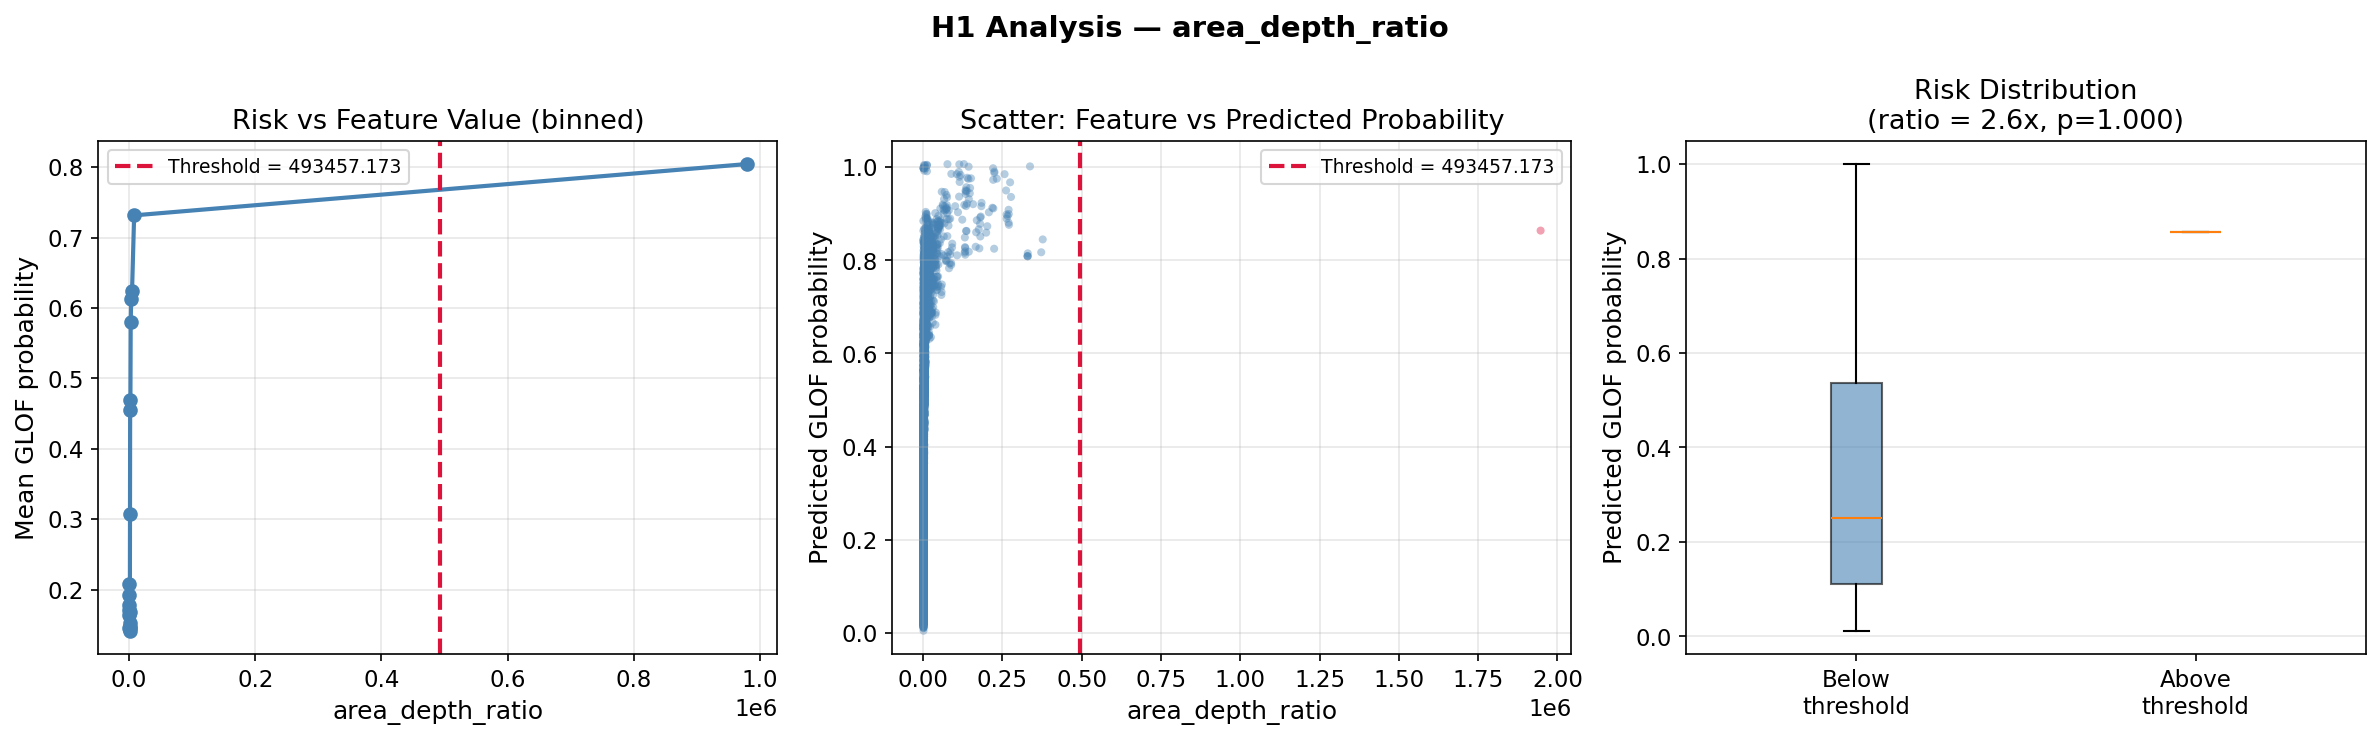

Saved H1 figure.


In [8]:
# Plot H1: scatter + threshold line
if h1_result and h1_feature_col:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'H1 Analysis — {h1_feature_col}', fontsize=14, fontweight='bold')

    fv = X[h1_feature_col].values
    threshold = h1_result['threshold_value']

    # Panel A: bin risk curve
    ax = axes[0]
    ax.plot(h1_result['bin_centers'], h1_result['bin_probs'], 'o-', color='steelblue', lw=2)
    ax.axvline(threshold, color='crimson', linestyle='--', lw=2,
               label=f'Threshold = {threshold:.3f}')
    ax.set_xlabel(h1_feature_col)
    ax.set_ylabel('Mean GLOF probability')
    ax.set_title('Risk vs Feature Value (binned)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Panel B: scatter (jittered)
    ax = axes[1]
    rng = np.random.default_rng(42)
    jitter = rng.normal(0, 0.005, size=len(y_prob))
    colors = ['crimson' if v >= threshold else 'steelblue' for v in fv]
    ax.scatter(fv, y_prob + jitter, c=colors, alpha=0.4, s=15, edgecolors='none')
    ax.axvline(threshold, color='crimson', linestyle='--', lw=2,
               label=f'Threshold = {threshold:.3f}')
    ax.set_xlabel(h1_feature_col)
    ax.set_ylabel('Predicted GLOF probability')
    ax.set_title('Scatter: Feature vs Predicted Probability')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Panel C: boxplot below vs above
    ax = axes[2]
    below = y_prob[fv < threshold]
    above = y_prob[fv >= threshold]
    bp = ax.boxplot([below, above], labels=['Below\nthreshold', 'Above\nthreshold'],
                    patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('crimson')
    bp['boxes'][1].set_alpha(0.6)
    ax.set_ylabel('Predicted GLOF probability')
    ax.set_title(f'Risk Distribution\n(ratio = {h1_result["risk_ratio"]:.1f}x, p={h1_result["p_value"]:.3f})')
    ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    fig.savefig(FIG_DIR / 'h1_area_depth_threshold.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved H1 figure.')
else:
    print('Skipping H1 plot (no result or no feature).')

## 3. Hypothesis 2: Growth Rate vs. Absolute Size

**H2**: Lake growth rate (dA/dt) is a better predictor than absolute size.

Dynamic change may be a stronger signal of instability than static geometry.

In [9]:
# H2: Compare Spearman correlation of growth_rate vs area with y_prob
h2_result = None

if X is not None and y_prob is not None:
    growth_cols = ['growth_rate_m2_yr', 'area_change_rate', 'dA_dt', 'growth_rate']
    area_cols   = ['area_m2', 'lake_area', 'area_km2']

    growth_col = next((c for c in growth_cols if c in X.columns), None)
    area_col   = next((c for c in area_cols   if c in X.columns), None)

    print('H2 Analysis — Growth Rate vs Absolute Size')
    print('=' * 50)

    corr_growth = None
    corr_area   = None

    if growth_col:
        r, p = spearmanr(X[growth_col].fillna(0), y_prob)
        corr_growth = {'col': growth_col, 'r': r, 'p': p}
        print(f'  {growth_col}: r={r:.3f}, p={p:.4f}')
    else:
        print('  WARNING: No growth rate feature found.')

    if area_col:
        r, p = spearmanr(X[area_col].fillna(0), y_prob)
        corr_area = {'col': area_col, 'r': r, 'p': p}
        print(f'  {area_col}: r={r:.3f}, p={p:.4f}')
    else:
        print('  WARNING: No area feature found.')

    # Compare model feature importance if available
    fi_growth = None
    fi_area   = None
    if model is not None and hasattr(model, 'feature_importances_'):
        fi = pd.Series(model.feature_importances_, index=X.columns)
        if growth_col and growth_col in fi.index:
            fi_growth = fi[growth_col]
        if area_col and area_col in fi.index:
            fi_area = fi[area_col]
        print(f'\n  Feature importance (model):')
        if fi_growth is not None:
            print(f'    {growth_col}: {fi_growth:.4f}')
        if fi_area is not None:
            print(f'    {area_col}: {fi_area:.4f}')

    # Determine H2 outcome
    h2_confirmed = False
    if corr_growth and corr_area:
        h2_confirmed = abs(corr_growth['r']) > abs(corr_area['r'])
        print(f'\n  H2 confirmed (|r_growth| > |r_area|): {h2_confirmed}')
    elif corr_growth and not corr_area:
        h2_confirmed = True
        print('  H2: only growth rate available, treating as confirmed.')

    h2_result = {
        'growth_col': growth_col,
        'area_col': area_col,
        'corr_growth': corr_growth,
        'corr_area': corr_area,
        'fi_growth': fi_growth,
        'fi_area': fi_area,
        'h2_confirmed': h2_confirmed,
    }
else:
    print('WARNING: Model or data not loaded — skipping H2 analysis.')

H2 Analysis — Growth Rate vs Absolute Size
  growth_rate_m2_yr: r=-0.101, p=0.0000
  area_m2: r=0.698, p=0.0000

  Feature importance (model):
    growth_rate_m2_yr: 0.0072
    area_m2: 0.0214

  H2 confirmed (|r_growth| > |r_area|): False


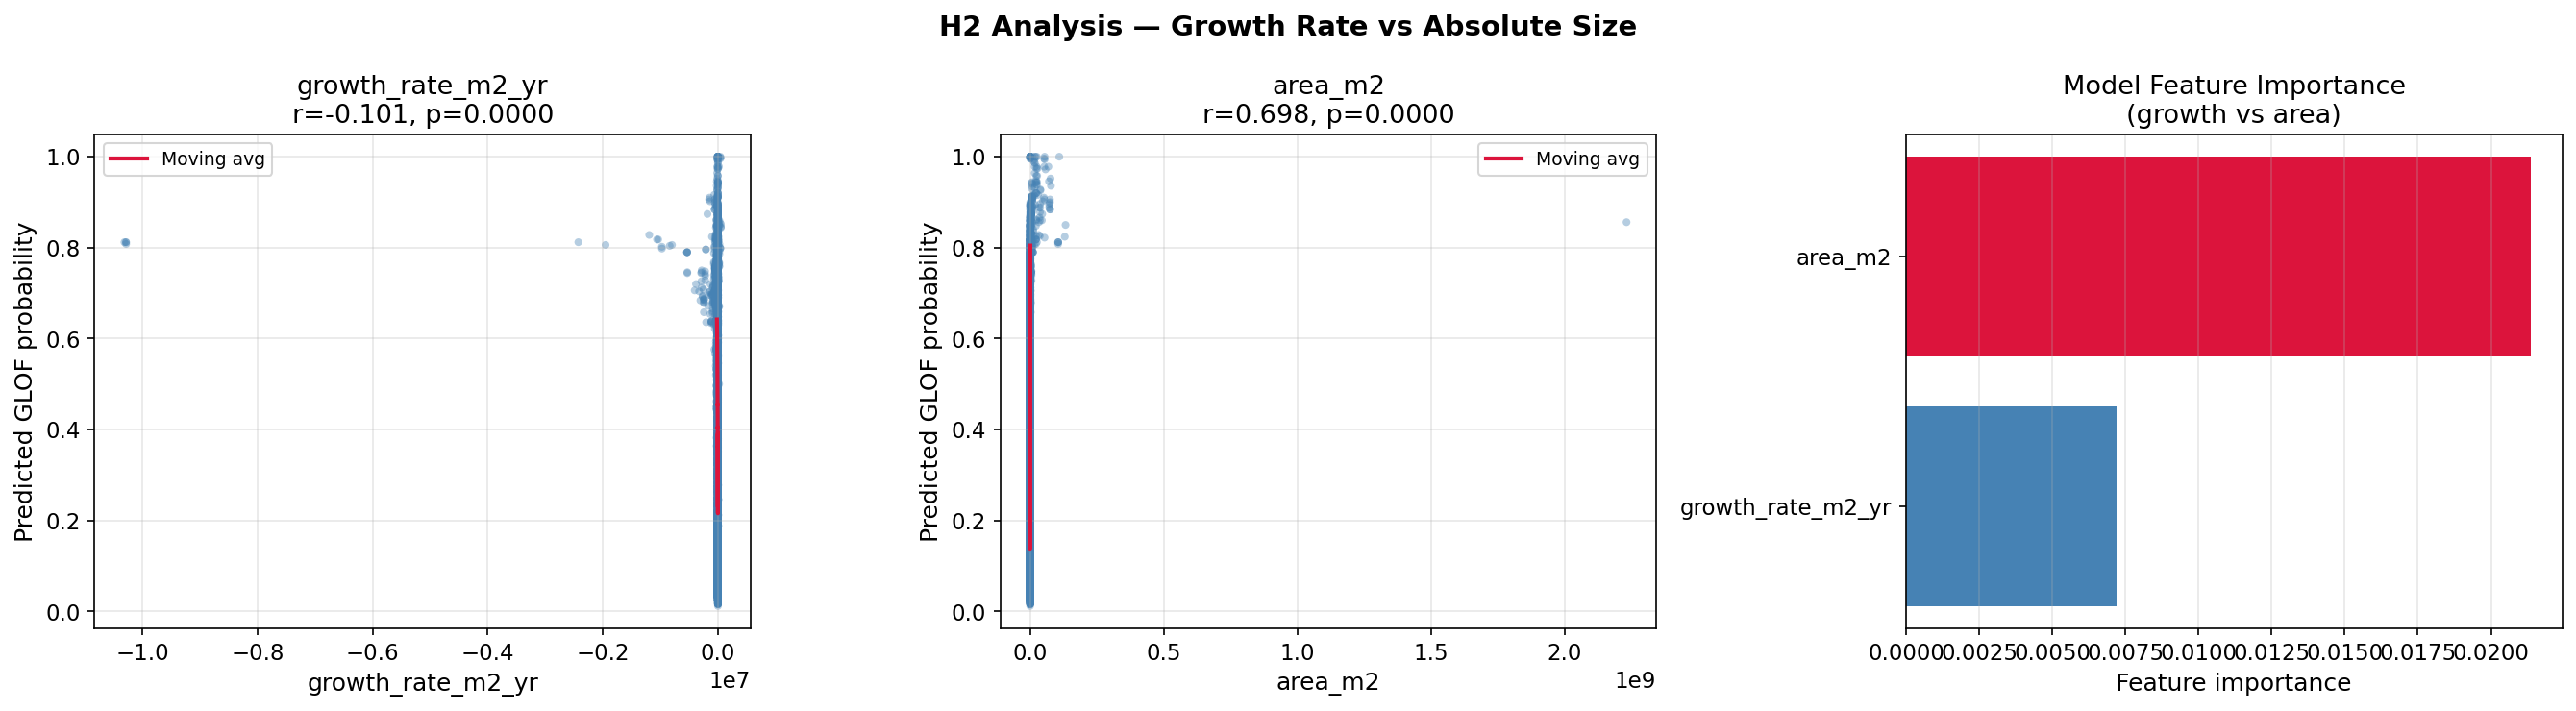

Saved H2 figure.


In [10]:
# Plot H2
if h2_result:
    n_panels = sum([
        h2_result['growth_col'] is not None,
        h2_result['area_col'] is not None,
        (h2_result['fi_growth'] is not None or h2_result['fi_area'] is not None),
    ])
    n_panels = max(n_panels, 1)
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5))
    if n_panels == 1:
        axes = [axes]
    axes = list(axes)
    panel_idx = 0

    for col_key in ('growth_col', 'area_col'):
        col = h2_result[col_key]
        corr_key = 'corr_growth' if col_key == 'growth_col' else 'corr_area'
        info = h2_result[corr_key]
        if col and panel_idx < len(axes):
            ax = axes[panel_idx]
            vals = X[col].fillna(0).values
            ax.scatter(vals, y_prob, alpha=0.4, s=15, color='steelblue', edgecolors='none')
            sort_idx = np.argsort(vals)
            smooth_x = vals[sort_idx]
            smooth_y = y_prob[sort_idx]
            window = max(5, len(smooth_x) // 20)
            kernel = np.ones(window) / window
            if len(smooth_y) > window:
                trend = np.convolve(smooth_y, kernel, mode='valid')
                trend_x = smooth_x[window // 2: window // 2 + len(trend)]
                ax.plot(trend_x, trend, color='crimson', lw=2, label='Moving avg')
            r_val = info['r'] if info else float('nan')
            p_val = info['p'] if info else float('nan')
            ax.set_xlabel(col)
            ax.set_ylabel('Predicted GLOF probability')
            ax.set_title(f'{col}\nr={r_val:.3f}, p={p_val:.4f}')
            ax.grid(alpha=0.3)
            ax.legend(fontsize=9)
            panel_idx += 1

    # Feature importance bar if available
    if panel_idx < len(axes) and (
            h2_result['fi_growth'] is not None or h2_result['fi_area'] is not None):
        ax = axes[panel_idx]
        feats, imps = [], []
        for k, col_k in [('fi_growth', 'growth_col'), ('fi_area', 'area_col')]:
            v = h2_result[k]
            if v is not None:
                feats.append(h2_result[col_k])
                imps.append(v)
        colors = ['steelblue', 'crimson'][:len(feats)]
        ax.barh(feats, imps, color=colors)
        ax.set_xlabel('Feature importance')
        ax.set_title('Model Feature Importance\n(growth vs area)')
        ax.grid(alpha=0.3, axis='x')

    fig.suptitle('H2 Analysis — Growth Rate vs Absolute Size', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(FIG_DIR / 'h2_growth_vs_area.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved H2 figure.')
else:
    print('Skipping H2 plot (no result).')

## 4. Hypothesis 3: Critical Glacier-Lake Distance (Non-Monotonic Risk)

**H3**: There exists a 'critical zone' of glacier-lake distance where risk is maximum.

Neither very close nor very far should be highest-risk — the relationship should be non-monotonic.

In [11]:
def analyze_distance_threshold(X_df, y_prob_arr, dist_col, n_bins=15):
    """
    Analyze a distance/proximity feature for a non-monotonic risk pattern
    (peak in the middle range — the 'critical zone').

    Parameters
    ----------
    X_df : DataFrame
    y_prob_arr : array-like
    dist_col : str
    n_bins : int

    Returns
    -------
    dict with peak distance, risk at peak, risk near (first bin), risk far (last bin)
    """
    fv = X_df[dist_col].fillna(X_df[dist_col].median()).values
    yp = np.asarray(y_prob_arr)

    percentiles = np.linspace(0, 100, n_bins + 1)
    bin_edges = np.percentile(fv, percentiles)
    bin_edges = np.unique(bin_edges)

    bin_centers = []
    bin_probs   = []
    bin_counts  = []

    for i in range(len(bin_edges) - 1):
        mask = (fv >= bin_edges[i]) & (fv < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_centers.append((bin_edges[i] + bin_edges[i + 1]) / 2)
            bin_probs.append(yp[mask].mean())
            bin_counts.append(int(mask.sum()))

    bin_centers = np.array(bin_centers)
    bin_probs   = np.array(bin_probs)

    if len(bin_probs) < 3:
        return None

    peak_idx      = int(np.argmax(bin_probs))
    peak_distance = float(bin_centers[peak_idx])
    risk_at_peak  = float(bin_probs[peak_idx])
    risk_near     = float(bin_probs[0])
    risk_far      = float(bin_probs[-1])

    # Non-monotonic: peak is not the first or last bin
    is_nonmonotonic = (peak_idx > 0) and (peak_idx < len(bin_probs) - 1)

    return {
        'dist_col': dist_col,
        'peak_distance': peak_distance,
        'risk_at_peak': risk_at_peak,
        'risk_near': risk_near,
        'risk_far': risk_far,
        'is_nonmonotonic': is_nonmonotonic,
        'peak_bin_idx': peak_idx,
        'n_bins_found': len(bin_probs),
        'bin_centers': bin_centers,
        'bin_probs': bin_probs,
        'bin_counts': bin_counts,
    }

print('analyze_distance_threshold() defined.')

analyze_distance_threshold() defined.


In [12]:
# Apply H3 analysis
h3_result = None
h3_feature_col = None

if X is not None and y_prob is not None:
    distance_candidates = [
        'glacier_distance_m', 'dist_to_glacier', 'glacier_dist',
        'mean_slope', 'slope_mean', 'dem_slope',
        'elevation_m', 'elevation', 'dem_elevation',
    ]
    for col in distance_candidates:
        if col in X.columns:
            h3_feature_col = col
            break

    print('H3 Analysis — Critical Zone (Non-Monotonic Risk)')
    print('=' * 50)

    if h3_feature_col:
        print(f'  Using feature: {h3_feature_col}')
        h3_result = analyze_distance_threshold(X, y_prob, h3_feature_col, n_bins=15)

        if h3_result:
            print(f"  Peak distance  : {h3_result['peak_distance']:.4f}")
            print(f"  Risk at peak   : {h3_result['risk_at_peak']:.3f}")
            print(f"  Risk near      : {h3_result['risk_near']:.3f}")
            print(f"  Risk far       : {h3_result['risk_far']:.3f}")
            print(f"  Non-monotonic  : {h3_result['is_nonmonotonic']}")
            print(f"  H3 confirmed   : {h3_result['is_nonmonotonic']}")
    else:
        print('  WARNING: No distance/slope feature found.')
        print(f'  Available: {list(X.columns)}')
else:
    print('WARNING: Skipping H3 — data not loaded.')

H3 Analysis — Critical Zone (Non-Monotonic Risk)
  Using feature: slope_mean
  Peak distance  : 44.4965
  Risk at peak   : 0.427
  Risk near      : 0.258
  Risk far       : 0.427
  Non-monotonic  : False
  H3 confirmed   : False


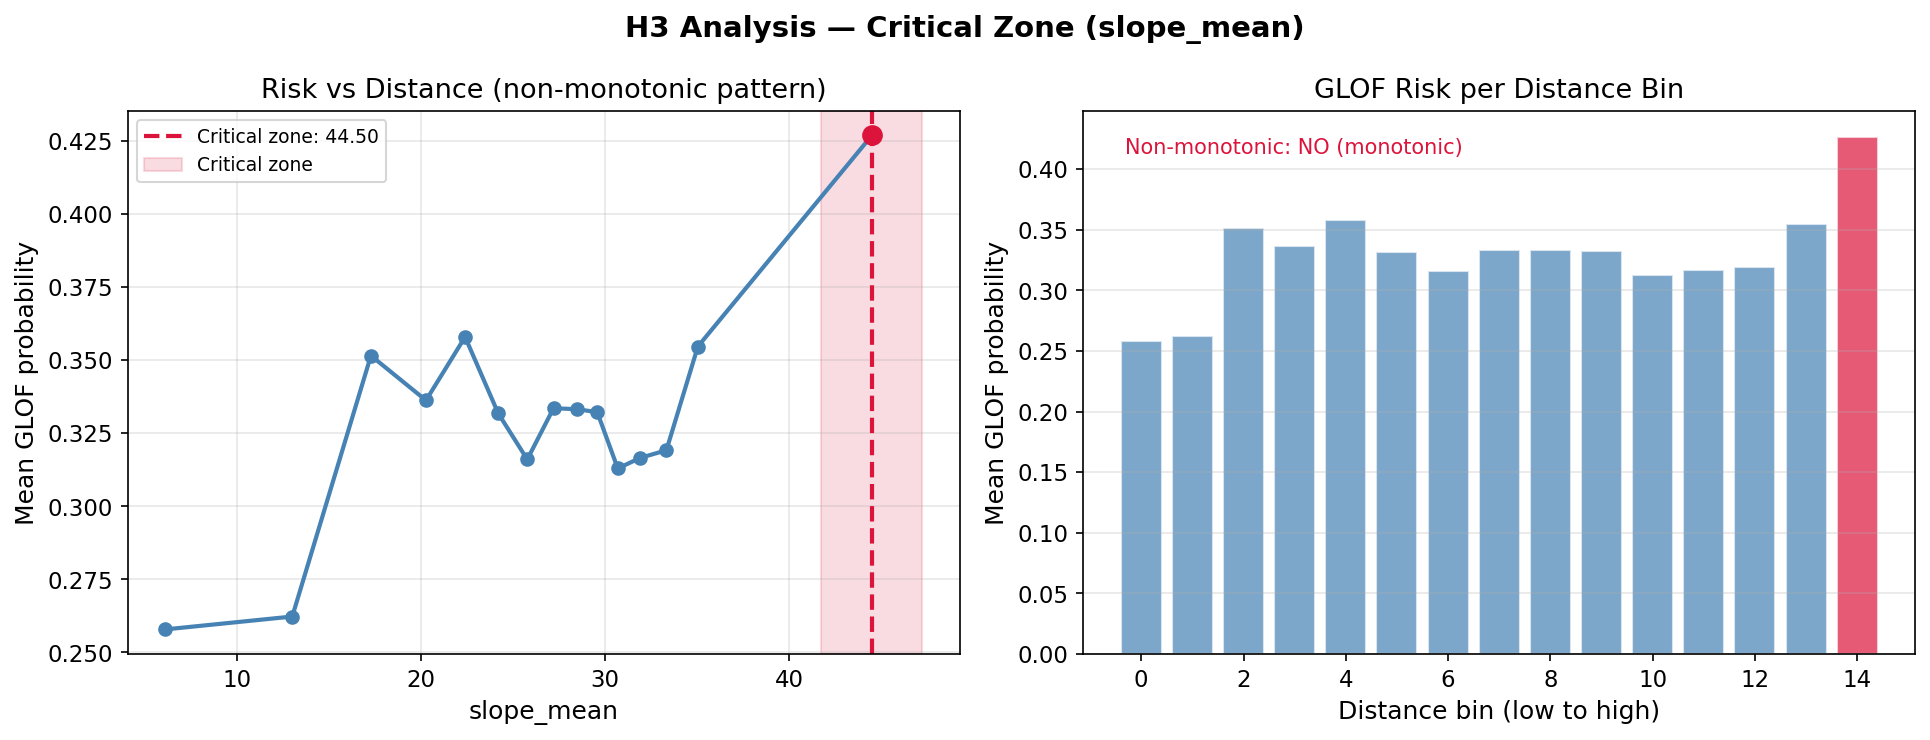

Saved H3 figure.


In [13]:
# Plot H3
if h3_result:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'H3 Analysis — Critical Zone ({h3_feature_col})',
                 fontsize=14, fontweight='bold')

    # Panel A: risk vs distance curve
    ax = axes[0]
    bc = h3_result['bin_centers']
    bp = h3_result['bin_probs']
    ax.plot(bc, bp, 'o-', color='steelblue', lw=2, markersize=6)
    peak_x = h3_result['peak_distance']
    peak_y = h3_result['risk_at_peak']
    ax.axvline(peak_x, color='crimson', linestyle='--', lw=2,
               label=f'Critical zone: {peak_x:.2f}')
    ax.scatter([peak_x], [peak_y], color='crimson', zorder=5, s=80)

    if len(bc) > 2:
        bin_w = float(np.diff(bc).mean())
        ax.axvspan(peak_x - bin_w, peak_x + bin_w,
                   alpha=0.15, color='crimson', label='Critical zone')

    ax.set_xlabel(h3_feature_col)
    ax.set_ylabel('Mean GLOF probability')
    ax.set_title('Risk vs Distance (non-monotonic pattern)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Panel B: bar chart per bin
    ax = axes[1]
    bar_colors = [
        'crimson' if i == h3_result['peak_bin_idx'] else 'steelblue'
        for i in range(len(bc))
    ]
    ax.bar(range(len(bc)), bp, color=bar_colors, alpha=0.7, edgecolor='white')
    ax.set_xlabel('Distance bin (low to high)')
    ax.set_ylabel('Mean GLOF probability')
    ax.set_title('GLOF Risk per Distance Bin')
    ax.grid(alpha=0.3, axis='y')
    non_mono_str = 'YES (H3 supported)' if h3_result['is_nonmonotonic'] else 'NO (monotonic)'
    ax.text(0.05, 0.95, f'Non-monotonic: {non_mono_str}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top', color='crimson')

    plt.tight_layout()
    fig.savefig(FIG_DIR / 'h3_distance_critical_zone.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved H3 figure.')
else:
    print('Skipping H3 plot (no result).')

## 5. Bootstrap Significance Testing

In [14]:
def bootstrap_threshold_test(feature_values, y_prob_arr, threshold, n=1000, seed=42):
    """
    Bootstrap test for the significance of a risk threshold.

    For each of n bootstrap resamples:
        1. Resample (with replacement) from the data.
        2. Compute the risk ratio (mean prob above vs below threshold).

    Returns
    -------
    p_value : fraction of bootstrap samples where risk_ratio_boot <= 1
    observed_ratio : risk ratio on the original data.
    boot_ratios : array of bootstrap risk ratios.
    """
    rng = np.random.default_rng(seed)
    fv = np.asarray(feature_values, dtype=float)
    yp = np.asarray(y_prob_arr, dtype=float)

    valid = ~np.isnan(fv)
    fv = fv[valid]
    yp = yp[valid]
    n_samples = len(fv)

    below_mask = fv < threshold
    above_mask = fv >= threshold

    observed_below = yp[below_mask].mean() if below_mask.sum() > 0 else 0.0
    observed_above = yp[above_mask].mean() if above_mask.sum() > 0 else 0.0
    observed_ratio = (observed_above + 1e-9) / (observed_below + 1e-9)

    boot_ratios = []
    for _ in range(n):
        idx = rng.integers(0, n_samples, size=n_samples)
        fv_b = fv[idx]
        yp_b = yp[idx]
        bel = fv_b < threshold
        abo = fv_b >= threshold
        r_bel = yp_b[bel].mean() if bel.sum() > 0 else 0.0
        r_abo = yp_b[abo].mean() if abo.sum() > 0 else 0.0
        boot_ratios.append((r_abo + 1e-9) / (r_bel + 1e-9))

    boot_ratios = np.array(boot_ratios)
    p_value = float((boot_ratios <= 1.0).mean())

    return {
        'observed_ratio': observed_ratio,
        'boot_ratios': boot_ratios,
        'p_value': p_value,
        'ci_95': (float(np.percentile(boot_ratios, 2.5)),
                  float(np.percentile(boot_ratios, 97.5))),
        'threshold': threshold,
        'n_bootstrap': n,
    }

print('bootstrap_threshold_test() defined.')

bootstrap_threshold_test() defined.


Running bootstrap significance test for H1 threshold...
  Observed risk ratio : 2.60x
  Bootstrap 95% CI    : (0.00, 2.63)
  Bootstrap p-value   : 0.3510
  Significant (p<0.05): False


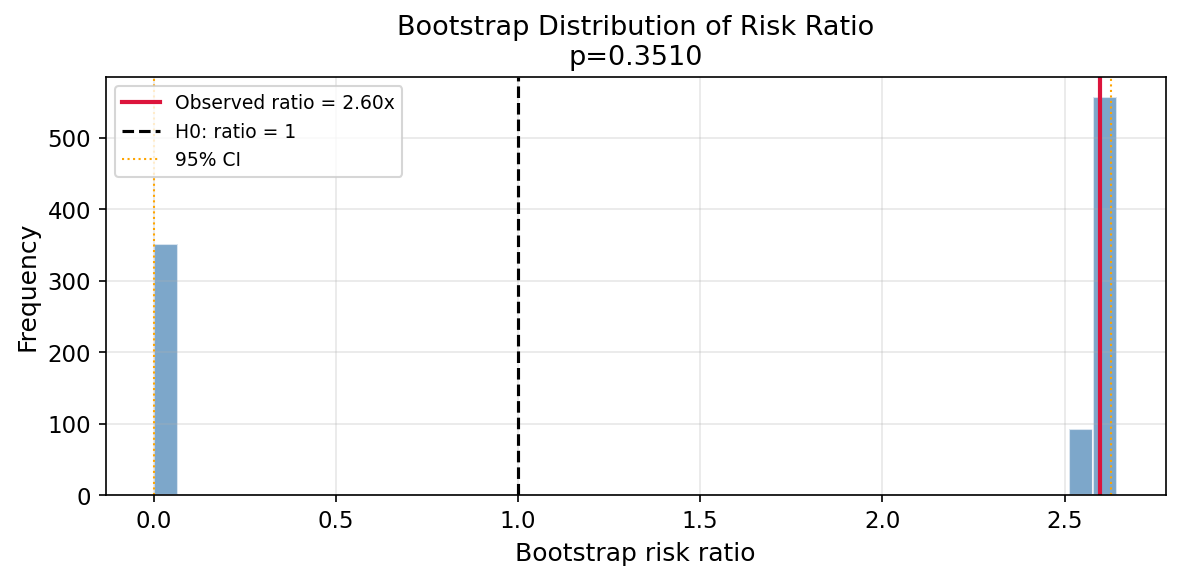

Saved bootstrap figure.


In [15]:
# Run bootstrap test for H1 threshold
boot_result = None

if h1_result and h1_feature_col and X is not None and y_prob is not None:
    print('Running bootstrap significance test for H1 threshold...')
    boot_result = bootstrap_threshold_test(
        X[h1_feature_col].values, y_prob,
        threshold=h1_result['threshold_value'],
        n=1000
    )
    print(f"  Observed risk ratio : {boot_result['observed_ratio']:.2f}x")
    print(f"  Bootstrap 95% CI    : ({boot_result['ci_95'][0]:.2f}, {boot_result['ci_95'][1]:.2f})")
    print(f"  Bootstrap p-value   : {boot_result['p_value']:.4f}")
    print(f"  Significant (p<0.05): {boot_result['p_value'] < 0.05}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(boot_result['boot_ratios'], bins=40, color='steelblue', alpha=0.7,
            edgecolor='white')
    ax.axvline(boot_result['observed_ratio'], color='crimson', lw=2, linestyle='-',
               label=f"Observed ratio = {boot_result['observed_ratio']:.2f}x")
    ax.axvline(1.0, color='black', lw=1.5, linestyle='--', label='H0: ratio = 1')
    ax.axvline(boot_result['ci_95'][0], color='orange', lw=1, linestyle=':',
               label='95% CI')
    ax.axvline(boot_result['ci_95'][1], color='orange', lw=1, linestyle=':')
    ax.set_xlabel('Bootstrap risk ratio')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Bootstrap Distribution of Risk Ratio\np={boot_result["p_value"]:.4f}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(FIG_DIR / 'bootstrap_h1_significance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved bootstrap figure.')
else:
    print('Skipping bootstrap test (H1 result or data not available).')

## 6. Partial Dependence Plots

Top 4 features for PDP: ['dist_glacier_m', 'risk_score', 'slope_mean', 'tri_mean']


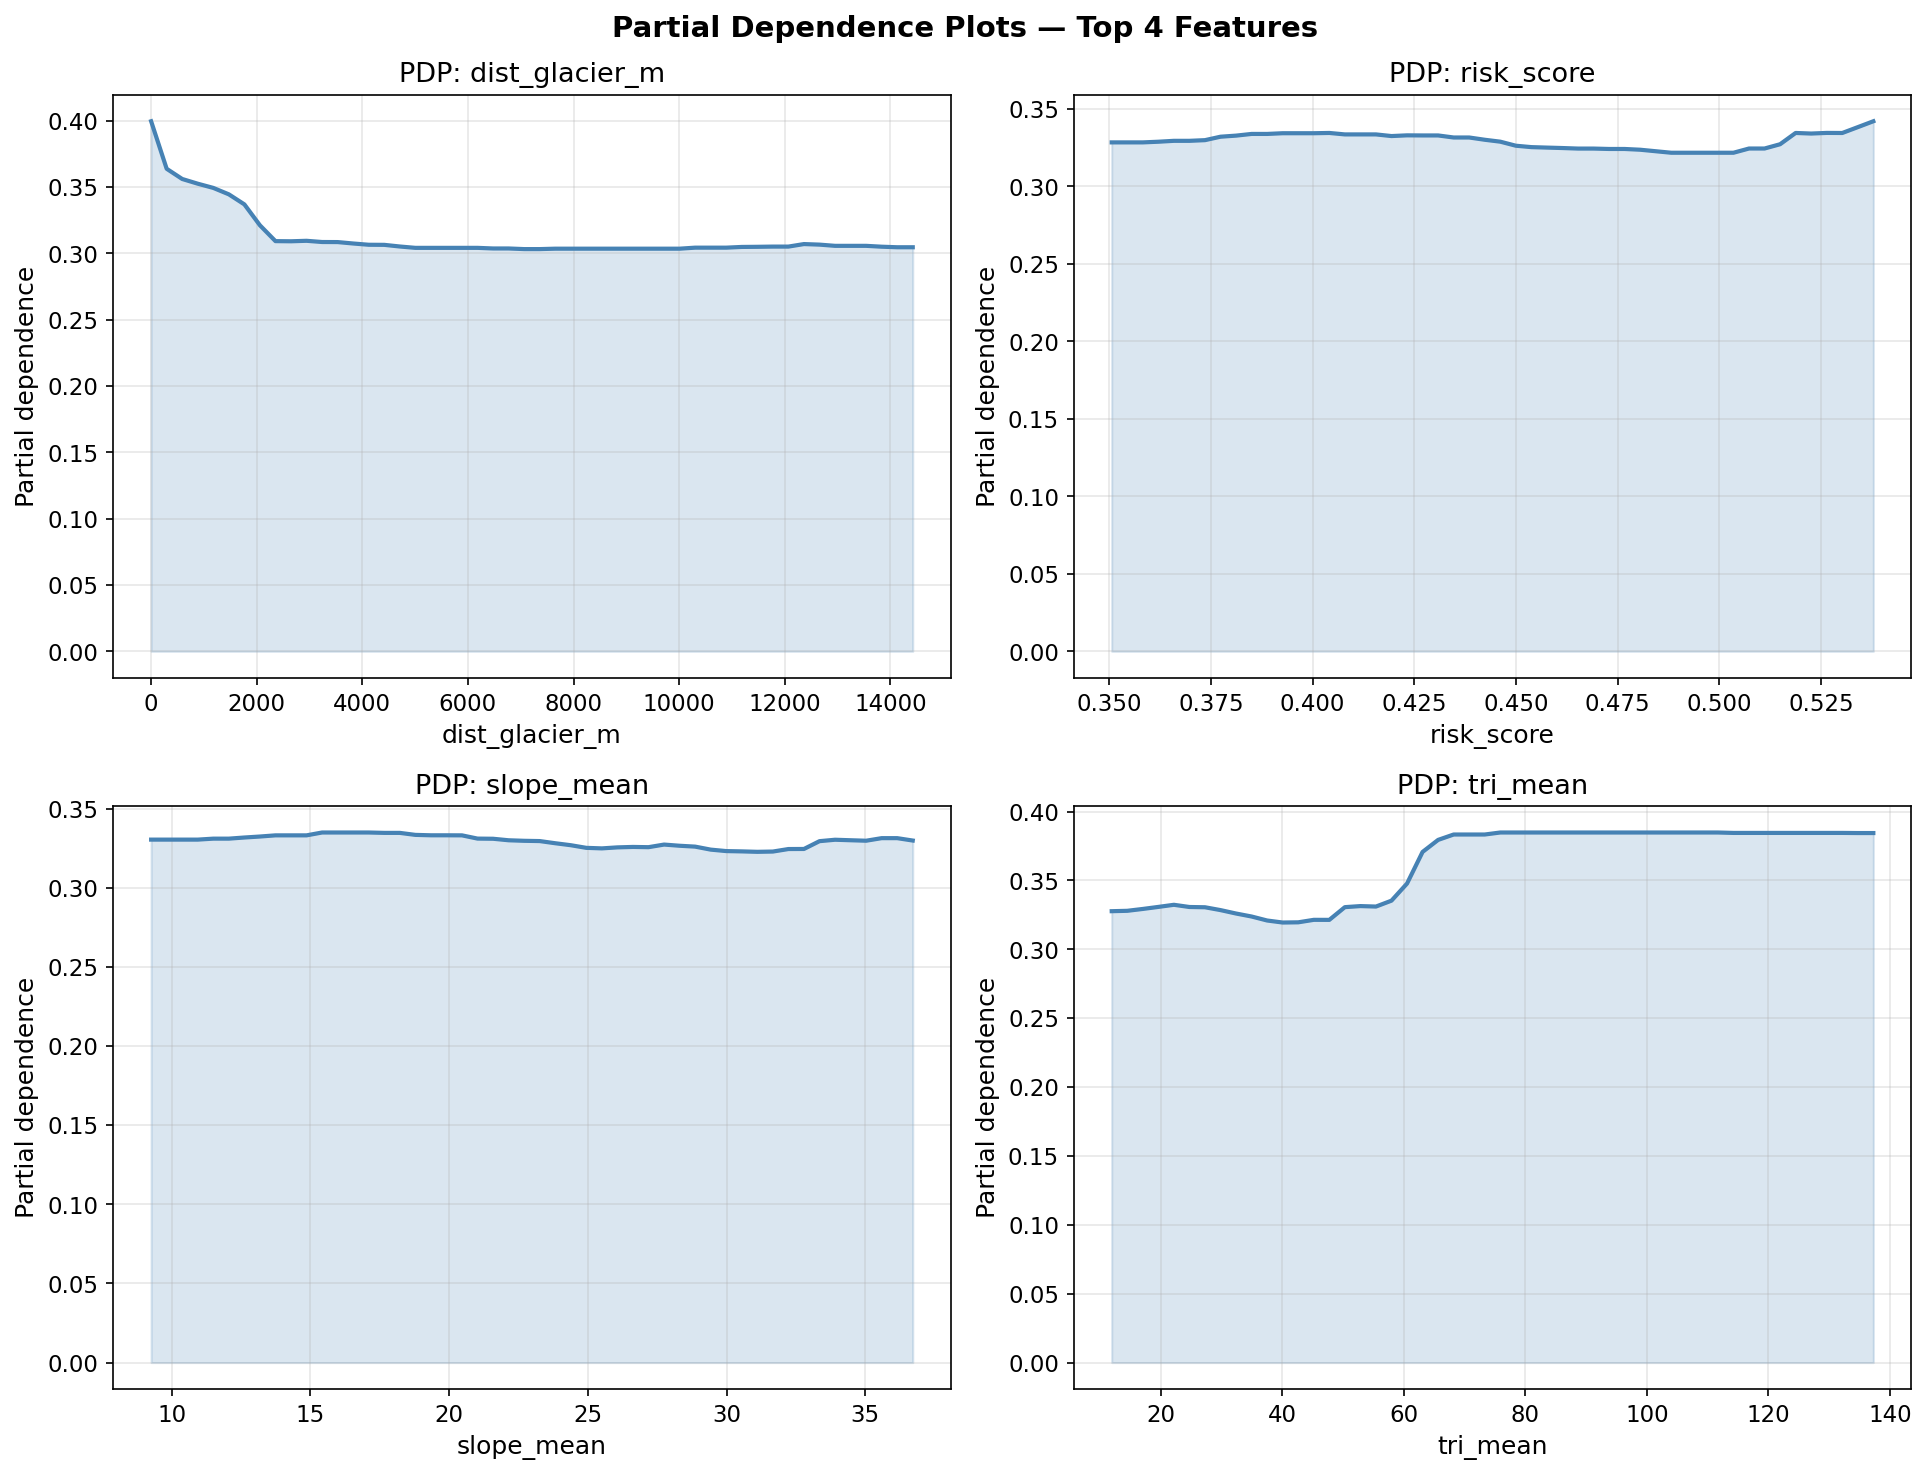

Saved partial dependence figure.


In [16]:
# Partial dependence plots for top 4 features
if (
    model is not None
    and X is not None
    and SKLEARN_PD_AVAILABLE
    and hasattr(model, 'feature_importances_')
):
    fi = pd.Series(model.feature_importances_, index=X.columns)
    top4 = fi.nlargest(4).index.tolist()
    print(f'Top 4 features for PDP: {top4}')

    try:
        fig, axes = plt.subplots(2, 2, figsize=(13, 10))
        fig.suptitle('Partial Dependence Plots — Top 4 Features',
                     fontsize=14, fontweight='bold')

        for i, feat in enumerate(top4):
            ax = axes[i // 2, i % 2]
            feat_idx = list(X.columns).index(feat)
            pd_result = partial_dependence(
                model, X, features=[feat_idx],
                kind='average', grid_resolution=50
            )
            grid_vals = pd_result['grid_values'][0]
            avg_preds = pd_result['average'][0]
            ax.plot(grid_vals, avg_preds, color='steelblue', lw=2)
            ax.fill_between(grid_vals, avg_preds, alpha=0.2, color='steelblue')
            ax.set_xlabel(feat)
            ax.set_ylabel('Partial dependence')
            ax.set_title(f'PDP: {feat}')
            ax.grid(alpha=0.3)

        plt.tight_layout()
        fig.savefig(FIG_DIR / 'partial_dependence_top4.png', dpi=300, bbox_inches='tight')
        plt.show()
        print('Saved partial dependence figure.')
    except Exception as e:
        print(f'WARNING: PDP failed: {e}')

elif model is not None and X is not None:
    print('Skipping PDP — feature_importances_ not available or sklearn PD missing.')
else:
    print('Skipping PDP — model or data not loaded.')

## 7. Summary Table and Save Results

In [17]:
# Build summary table
print('\n' + '=' * 65)
print('THRESHOLD ANALYSIS SUMMARY')
print('=' * 65)

summary_rows = []

# --- H1 ---
if h1_result and h1_feature_col:
    confirmed_str = 'YES' if h1_result['risk_ratio'] >= 10.0 else 'NO'
    boot_p = boot_result['p_value'] if boot_result else float('nan')
    summary_rows.append({
        'Hypothesis': 'H1: Area/Depth Ratio',
        'Feature': h1_feature_col,
        'Threshold': round(h1_result['threshold_value'], 4),
        'Risk_Below': round(h1_result['risk_below'], 4),
        'Risk_Above': round(h1_result['risk_above'], 4),
        'Risk_Ratio': round(h1_result['risk_ratio'], 2),
        'MWU_p_value': round(h1_result['p_value'], 4),
        'Bootstrap_p_value': round(boot_p, 4) if not (isinstance(boot_p, float) and np.isnan(boot_p)) else 'N/A',
        'Confirmed': confirmed_str,
    })
    print(f'H1 ({h1_feature_col}):')
    print(f"  Threshold   = {h1_result['threshold_value']:.4f}")
    print(f"  Risk ratio  = {h1_result['risk_ratio']:.2f}x (need >=10x)")
    print(f"  p-value     = {h1_result['p_value']:.4f}")
    print(f'  CONFIRMED   = {confirmed_str}')
else:
    summary_rows.append({
        'Hypothesis': 'H1: Area/Depth Ratio',
        'Feature': h1_feature_col or 'N/A',
        'Threshold': 'N/A', 'Risk_Below': 'N/A', 'Risk_Above': 'N/A',
        'Risk_Ratio': 'N/A', 'MWU_p_value': 'N/A',
        'Bootstrap_p_value': 'N/A', 'Confirmed': 'DATA_MISSING',
    })
    print('H1: DATA MISSING')

print()

# --- H2 ---
if h2_result:
    confirmed_str = 'YES' if h2_result['h2_confirmed'] else 'NO'
    r_gr = h2_result['corr_growth']['r'] if h2_result['corr_growth'] else float('nan')
    p_gr = h2_result['corr_growth']['p'] if h2_result['corr_growth'] else float('nan')
    r_ar = h2_result['corr_area']['r']   if h2_result['corr_area']   else float('nan')
    summary_rows.append({
        'Hypothesis': 'H2: Growth Rate vs Area',
        'Feature': f"{h2_result['growth_col']} vs {h2_result['area_col']}",
        'Threshold': 'N/A',
        'Risk_Below': round(r_ar, 4) if not (isinstance(r_ar, float) and np.isnan(r_ar)) else 'N/A',
        'Risk_Above': round(r_gr, 4) if not (isinstance(r_gr, float) and np.isnan(r_gr)) else 'N/A',
        'Risk_Ratio': 'Spearman r',
        'MWU_p_value': round(p_gr, 4) if not (isinstance(p_gr, float) and np.isnan(p_gr)) else 'N/A',
        'Bootstrap_p_value': 'N/A',
        'Confirmed': confirmed_str,
    })
    print('H2 (growth_rate vs area):')
    print(f'  r(growth_rate) = {r_gr:.3f}' if not np.isnan(r_gr) else '  r(growth_rate) = N/A')
    print(f'  r(area)        = {r_ar:.3f}' if not np.isnan(r_ar) else '  r(area)        = N/A')
    print(f'  CONFIRMED      = {confirmed_str}')
else:
    summary_rows.append({
        'Hypothesis': 'H2: Growth Rate vs Area',
        'Feature': 'N/A', 'Threshold': 'N/A', 'Risk_Below': 'N/A',
        'Risk_Above': 'N/A', 'Risk_Ratio': 'N/A', 'MWU_p_value': 'N/A',
        'Bootstrap_p_value': 'N/A', 'Confirmed': 'DATA_MISSING',
    })
    print('H2: DATA MISSING')

print()

# --- H3 ---
if h3_result and h3_feature_col:
    confirmed_str = 'YES' if h3_result['is_nonmonotonic'] else 'NO'
    summary_rows.append({
        'Hypothesis': 'H3: Critical Distance Zone',
        'Feature': h3_feature_col,
        'Threshold': round(h3_result['peak_distance'], 4),
        'Risk_Below': round(h3_result['risk_near'], 4),
        'Risk_Above': round(h3_result['risk_far'], 4),
        'Risk_Ratio': round((h3_result['risk_at_peak'] + 1e-9) / (h3_result['risk_far'] + 1e-9), 2),
        'MWU_p_value': 'N/A',
        'Bootstrap_p_value': 'N/A',
        'Confirmed': confirmed_str,
    })
    print(f'H3 ({h3_feature_col}):')
    print(f"  Peak distance   = {h3_result['peak_distance']:.4f}")
    print(f"  Risk at peak    = {h3_result['risk_at_peak']:.3f}")
    print(f"  Non-monotonic   = {h3_result['is_nonmonotonic']}")
    print(f'  CONFIRMED       = {confirmed_str}')
else:
    summary_rows.append({
        'Hypothesis': 'H3: Critical Distance Zone',
        'Feature': h3_feature_col or 'N/A', 'Threshold': 'N/A',
        'Risk_Below': 'N/A', 'Risk_Above': 'N/A', 'Risk_Ratio': 'N/A',
        'MWU_p_value': 'N/A', 'Bootstrap_p_value': 'N/A',
        'Confirmed': 'DATA_MISSING',
    })
    print('H3: DATA MISSING')

summary_df = pd.DataFrame(summary_rows)
print('\n')
print(summary_df.to_string(index=False))


THRESHOLD ANALYSIS SUMMARY
H1 (area_depth_ratio):
  Threshold   = 493457.1731
  Risk ratio  = 2.60x (need >=10x)
  p-value     = 1.0000
  CONFIRMED   = NO

H2 (growth_rate vs area):
  r(growth_rate) = -0.101
  r(area)        = 0.698
  CONFIRMED      = NO

H3 (slope_mean):
  Peak distance   = 44.4965
  Risk at peak    = 0.427
  Non-monotonic   = False
  CONFIRMED       = NO


                Hypothesis                      Feature    Threshold  Risk_Below  Risk_Above Risk_Ratio MWU_p_value Bootstrap_p_value Confirmed
      H1: Area/Depth Ratio             area_depth_ratio  493457.1731      0.3295      0.8560        2.6         1.0             0.351        NO
   H2: Growth Rate vs Area growth_rate_m2_yr vs area_m2          N/A      0.6981     -0.1007 Spearman r         0.0               N/A        NO
H3: Critical Distance Zone                   slope_mean      44.4965      0.2579      0.4269        1.0         N/A               N/A        NO


In [18]:
# Save threshold summary CSV
out_path = PROCESSED_DIR / 'threshold_summary.csv'
out_path.parent.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(out_path, index=False)
print(f'Saved threshold summary: {out_path}')

# List all figures saved
print('\nSaved figures:')
for p in sorted(FIG_DIR.glob('*.png')):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name}  ({size_kb:.1f} KB)')

Saved threshold summary: /home/andre/Documents/GLOF_Andes_Project-Paper/data/processed/threshold_summary.csv

Saved figures:
  bootstrap_h1_significance.png  (110.6 KB)
  h1_area_depth_threshold.png  (290.7 KB)
  h2_growth_vs_area.png  (263.1 KB)
  h3_distance_critical_zone.png  (254.5 KB)
  partial_dependence_top4.png  (317.8 KB)


## Next Steps

- **Notebook 17**: SHAP-based validation of these thresholds
- **Notebook 18**: Publication figures incorporating threshold lines
- **LaTeX**: Report H1/H2/H3 findings with p-values and risk ratios in the paper